In [7]:
# kaggle kernel environment: 
# https://kkb-production.jupyter-proxy.kaggle.net/k/356643754/eyJhbGciOiJkaXIiLCJlbmMiOiJBMTI4Q0JDLUhTMjU2IiwidHlwIjoiSldUIn0..WekZ-VRucMoSubxV8GmYxA.O6i31xS2ZwrS9L3uvAX9j-u4bAfqDRmIf2euOGs_a1fwUhLzLlkAWyJY17EWYkmjtOALwMv82hoPMZO1tUI7bRG1kAQyRhg4zJvMiqzkMjm1rE4nw_0EMHRhmUOVLVtRRwXIjrJfD6nYG4E6qMfu2NZrcCiJWihg0PtalX-8PoBcMxAIiyo_kqOSouljlIYtEBMVMpvk7UNmml20n1DVTDmp3UVaFhzKQR6EqvsOL7UOOtnPT-AgwygYU3pkn46p.T3Jac8PVT8H_t7WeAgrVVw/proxy

import os
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

if os.path.exists('/kaggle/input'):
    print("Successfully connected to Kaggle's dataset environment")
    #for root, dirs, files in os.walk('/kaggle/input'):
     #   for file in files[:5]: 
      #      print(os.path.join(root, file))
else:
    print("Not connected, code running locally")


Successfully connected to Kaggle's dataset environment


In [ ]:
#001 10_01
#ecg data
ecg_data = pd.read_csv('/kaggle/input/datasets/sarabhian/d1namo-ecg-glucose-data/diabetes_subset_ecg_data/diabetes_subset_ecg_data/001/sensor_data/2014_10_01-10_09_39/2014_10_01-10_09_39_ECG.csv')

# sensor data
sensor_base = '/kaggle/input/datasets/sarabhian/d1namo-ecg-glucose-data/diabetes_subset_sensor_data/diabetes_subset_sensor_data/001/sensor_data/2014_10_01-10_09_39/'

accel = pd.read_csv(sensor_base + '2014_10_01-10_09_39_Accel.csv')
bb = pd.read_csv(sensor_base + '2014_10_01-10_09_39_BB.csv')
breathing = pd.read_csv(sensor_base + '2014_10_01-10_09_39_Breathing.csv')
rr = pd.read_csv(sensor_base + '2014_10_01-10_09_39_RR.csv')
summary = pd.read_csv(sensor_base + '2014_10_01-10_09_39_Summary.csv')
summary #average at each time recorded

,Time,HR,BR,SkinTemp,Posture,Activity,PeakAccel,BatteryVolts,BatteryLevel,BRAmplitude,...,SagittalPeak,DeviceTemp,StatusInfo,LinkQuality,RSSI,TxPower,CoreTemp,AuxADC1,AuxADC2,AuxADC3
0,01/10/2014 10:09:39.417,65,8.1,-3276.8,19,0.41,0.84,4.161,93,5973.0,...,0.39,24.9,528,255,-128,-128,6553.5,420,433,499
1,01/10/2014 10:09:40.417,65,8.1,-3276.8,9,0.51,1.03,4.161,93,5361.0,...,0.36,24.9,528,255,-128,-128,6553.5,419,428,485
2,01/10/2014 10:09:41.417,65,7.3,-3276.8,11,0.30,0.74,4.161,93,4733.0,...,0.12,24.9,528,255,-128,-128,6553.5,415,420,484
3,01/10/2014 10:09:42.417,65,7.3,-3276.8,18,0.43,0.98,4.161,93,4094.0,...,0.49,24.9,528,255,-128,-128,6553.5,415,422,484
4,01/10/2014 10:09:43.417,65,6.6,-3276.8,19,0.49,1.10,4.161,93,3566.0,...,0.44,24.9,528,255,-128,-128,6553.5,399,406,480
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44022,01/10/2014 22:23:21.417,0,7.6,-3276.8,28,0.25,0.46,3.781,30,2176.0,...,-0.18,34.3,528,255,-128,-128,37.1,415,422,483
44023,01/10/2014 22:23:22.417,0,7.6,-3276.8,26,0.65,1.12,3.781,30,2612.0,...,0.54,34.3,528,255,-128,-128,37.1,416,421,482
44024,01/10/2014 22:23:23.417,0,7.8,-3276.8,50,0.56,0.92,3.781,30,2340.0,...,0.39,34.3,528,255,-128,-128,37.1,414,420,483
44025,01/10/2014 22:23:24.417,0,7.8,-3276.8,68,0.37,0.51,3.781,30,2371.0,...,0.10,34.3,528,255,-128,-128,37.1,415,419,482


In [9]:
ecg_data

,Time,EcgWaveform
0,01/10/2014 10:09:39.417,297
1,01/10/2014 10:09:39.421,297
2,01/10/2014 10:09:39.425,297
3,01/10/2014 10:09:39.429,297
4,01/10/2014 10:09:39.433,297
...,...,...
11006745,01/10/2014 22:23:26.397,3798
11006746,01/10/2014 22:23:26.401,3798
11006747,01/10/2014 22:23:26.405,3798
11006748,01/10/2014 22:23:26.409,3798


In [13]:
accel

,Time,Vertical,Lateral,Sagittal
0,01/10/2014 10:09:39.417,2001,2076,2010
1,01/10/2014 10:09:39.427,1986,2070,1984
2,01/10/2014 10:09:39.437,1985,2072,1983
3,01/10/2014 10:09:39.447,1993,2069,1992
4,01/10/2014 10:09:39.457,1997,2063,2000
...,...,...,...,...
4402695,01/10/2014 22:23:26.367,2026,2122,2037
4402696,01/10/2014 22:23:26.377,2028,2120,2036
4402697,01/10/2014 22:23:26.387,2030,2118,2036
4402698,01/10/2014 22:23:26.397,2029,2116,2036


In [10]:
print(summary.columns)

Index(['Time', 'HR', 'BR', 'SkinTemp', 'Posture', 'Activity', 'PeakAccel',
       'BatteryVolts', 'BatteryLevel', 'BRAmplitude', 'BRNoise',
       'BRConfidence', 'ECGAmplitude', 'ECGNoise', 'HRConfidence', 'HRV',
       'SystemConfidence', 'GSR', 'ROGState', 'ROGTime', 'VerticalMin',
       'VerticalPeak', 'LateralMin', 'LateralPeak', 'SagittalMin',
       'SagittalPeak', 'DeviceTemp', 'StatusInfo', 'LinkQuality', 'RSSI',
       'TxPower', 'CoreTemp', 'AuxADC1', 'AuxADC2', 'AuxADC3'],
      dtype='object')


<Axes: title={'center': '001 10_01'}, xlabel='Time(min)'>

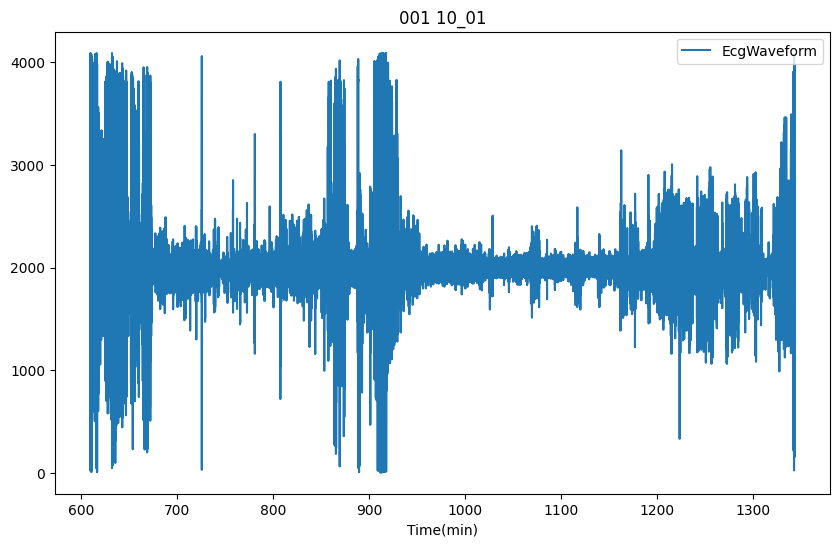

In [15]:
ecg_data['Time'] = pd.to_datetime(ecg_data['Time'])

ecg_data['Time(min)'] = (ecg_data['Time'].dt.hour * 60 
                        + ecg_data['Time'].dt.minute 
                        + ecg_data['Time'].dt.second / 60
                       )
ecg_data.plot(kind='line', x='Time(min)', y='EcgWaveform', figsize=(10,6), title='001 10_01')
